# V2.17 — Clinical Photo Augmentation Comparison

**Issue:** [#158](https://github.com/romanpoluden/revela/issues/158)  
**Branch:** `Rehma_Revela_Dermascopic`  
**Date:** 2026-05-21  
**Author:** Rehma Aziz  
**Scope:** Compare two clinical-photo augmentation strategies (mild, robust) against the existing baseline. No taxonomy change, no inference wiring change, no model promotion in code.

---

## Outcome Summary

**Neither strategy is promotable. Baseline `clinical_v2_effnet_b0` stays in production.**

| Metric | Threshold | Baseline | Mild aug | Robust aug |
|---|---|---|---|---|
| Combined macro-F1 | ≥ 0.6420 | 0.6447 ✓ | 0.6379 ✗ | 0.6556 ✓ |
| Balanced accuracy | ≥ 0.6571 | — | 0.6552 ✗ | 0.6726 ✓ |
| SCIN macro-F1 | ≥ 0.4028 | 0.3907 | 0.3922 ✗ | 0.3897 ✗ |
| Fitzpatrick macro-F1 | ≥ 0.6366 | 0.6411 ✓ | 0.6247 ✗ | 0.6583 ✓ |
| Lesion routing FN | ≤ 76 | 82 | 61 ✓ | 65 ✓ |

**Robust aug** passes all thresholds except SCIN macro-F1 (0.3897 vs 0.4028). SCIN underperformance is domain shift — not fixable by augmentation alone.  
**Mild aug** regresses on 4 of 5 criteria vs baseline.

Test set frozen throughout: `4b510381927f6265446a62cb990e69fd` ✓

## Setup

In [1]:
import hashlib
import json
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd

ROOT = "../../.."  # relative to this notebook

HISTORY = {
    "Baseline":   f"{ROOT}/models/clinical_v2_effnet_b0/training_history.csv",
    "Mild aug":   f"{ROOT}/models/clinical_v2_aug_mild_effnet_b0/training_history.csv",
    "Robust aug": f"{ROOT}/models/clinical_v2_aug_robust_effnet_b0/training_history.csv",
}
METRICS = {
    "Baseline":   f"{ROOT}/outputs/metrics/clinical_v2_test_metrics.json",
    "Mild aug":   f"{ROOT}/outputs/metrics/clinical_v2_aug_mild_test_metrics.json",
    "Robust aug": f"{ROOT}/outputs/metrics/clinical_v2_aug_robust_test_metrics.json",
}
SOURCE_METRICS = {
    "Baseline":   f"{ROOT}/outputs/metrics/clinical_v2_source_metrics.csv",
    "Mild aug":   f"{ROOT}/outputs/metrics/clinical_v2_aug_mild_source_metrics.csv",
    "Robust aug": f"{ROOT}/outputs/metrics/clinical_v2_aug_robust_source_metrics.csv",
}
COMPARISON_CSV = f"{ROOT}/outputs/metrics/clinical_v2_augmentation_comparison_table.csv"
CONFUSION_IMGS = {
    "Baseline":   f"{ROOT}/outputs/plots/clinical_v2_confusion_matrix.png",
    "Mild aug":   f"{ROOT}/outputs/plots/clinical_v2_aug_mild_confusion_matrix.png",
    "Robust aug": f"{ROOT}/outputs/plots/clinical_v2_aug_robust_confusion_matrix.png",
}
TEST_CSV  = f"{ROOT}/data/processed/clinical_v2/test.csv"
EXPECTED_HASH = "4b510381927f6265446a62cb990e69fd"

THRESHOLDS = {
    "combined_macro_f1":    0.6420,
    "balanced_accuracy":    0.6571,
    "scin_macro_f1":        0.4028,
    "fitzpatrick_macro_f1": 0.6366,
    "lesion_routing_fn":    76,
}

actual_hash = hashlib.md5(open(TEST_CSV, "rb").read()).hexdigest()
assert actual_hash == EXPECTED_HASH, f"Test hash mismatch: {actual_hash}"
print(f"Test set hash verified: {actual_hash} ✓")
print(f"Test rows: {len(pd.read_csv(TEST_CSV)):,}")
print("Setup complete.")

Test set hash verified: 4b510381927f6265446a62cb990e69fd ✓
Test rows: 1,515
Setup complete.


## Section 1 — Augmentation Strategies

All three strategies are implemented in `src/data/transforms.py` and selected via `augmentation_strategy` in the training config.

### Baseline
```
RandomResizedCrop(224, scale=(0.9, 1.0), ratio=(0.95, 1.05))
RandomHorizontalFlip(p=0.5)
RandomVerticalFlip(p=0.5)
ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02)
```

### Mild clinical (`mild_clinical`)
```
RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.9, 1.1))
RandomHorizontalFlip(p=0.5)
RandomRotation(degrees=10)
ColorJitter(brightness=0.15, contrast=0.15, saturation=0.05, hue=0.0)  # hue=0: skin color preserved
```
Changes: wider crop, rotation instead of vertical flip (body-site anatomy is directional), hue removed.

### Robust clinical (`robust_clinical`)
```
RandomResizedCrop(224, scale=(0.80, 1.0), ratio=(0.9, 1.1))
RandomHorizontalFlip(p=0.5)
RandomRotation(degrees=15)
ColorJitter(brightness=0.2, contrast=0.2, saturation=0.05, hue=0.0)
GaussianBlur(kernel_size=3, sigma=(0.1, 0.5))
RandomGrayscale(p=0.02)
```
Changes: wider crop range, more rotation, mild blur, very rare grayscale. hue=0.0 preserved.

**Note:** hue=0.0 in both clinical variants — erythema and pigmentation carry diagnostic signal; hue jitter risks corrupting that information.

## Section 2 — Training Results

In [2]:
histories = {name: pd.read_csv(path) for name, path in HISTORY.items()}

# Best val macro-F1 per variant
summary_rows = []
for name, h in histories.items():
    best = h.loc[h["val_macro_f1"].idxmax()]
    summary_rows.append({
        "Variant": name,
        "Best epoch": int(best["epoch"]),
        "Best val macro-F1": round(best["val_macro_f1"], 4),
        "Best val balanced-acc": round(best["val_balanced_accuracy"], 4),
        "Final train loss": round(h.iloc[-1]["train_loss"], 4),
    })

display(pd.DataFrame(summary_rows).set_index("Variant"))

,Best epoch,Best val macro-F1,Best val balanced-acc,Final train loss
Variant,,,,
Baseline,5,0.6758,0.6878,0.6057
Mild aug,5,0.6678,0.6891,0.5351
Robust aug,4,0.6982,0.7169,0.5864


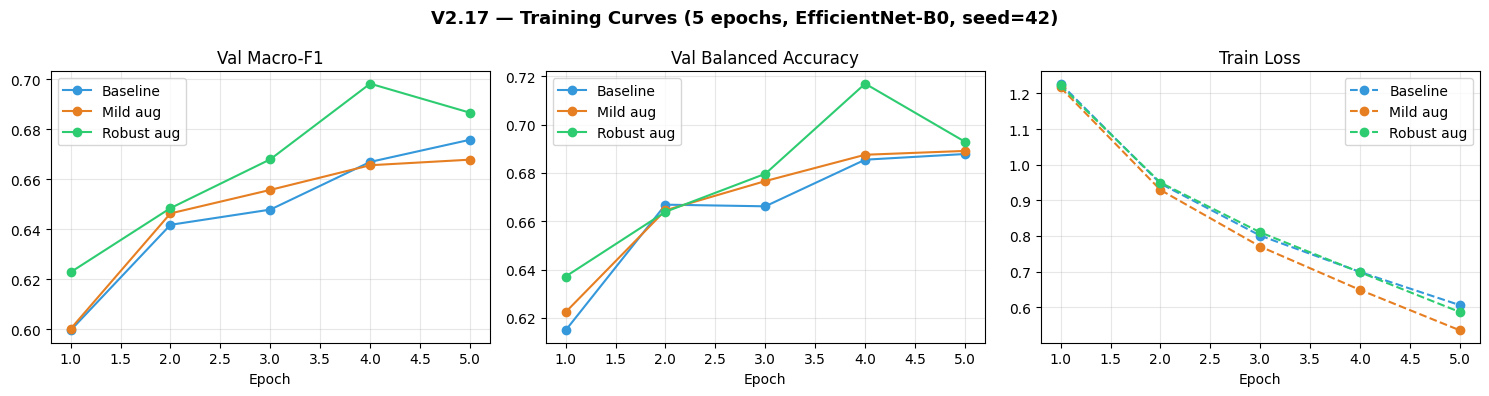

In [3]:
colors = {"Baseline": "#3498db", "Mild aug": "#e67e22", "Robust aug": "#2ecc71"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for name, h in histories.items():
    axes[0].plot(h["epoch"], h["val_macro_f1"], marker="o", label=name, color=colors[name])
    axes[1].plot(h["epoch"], h["val_balanced_accuracy"], marker="o", label=name, color=colors[name])
    axes[2].plot(h["epoch"], h["train_loss"], marker="o", linestyle="--", label=name, color=colors[name])

axes[0].set_title("Val Macro-F1")
axes[1].set_title("Val Balanced Accuracy")
axes[2].set_title("Train Loss")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("V2.17 — Training Curves (5 epochs, EfficientNet-B0, seed=42)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 3 — Test Set Evaluation

Frozen test set: 1,515 examples. Hash verified before first eval and after every variant eval.

In [4]:
metrics = {name: json.load(open(path)) for name, path in METRICS.items()}

rows = []
for name, m in metrics.items():
    lr = m["lesion_routing_class"]
    rows.append({
        "Variant": name,
        "Test accuracy": round(m["test_accuracy"], 4),
        "Macro-F1": round(m["macro_f1"], 4),
        "Balanced acc": round(m["balanced_accuracy"], 4),
        "Lesion precision": round(lr["precision"], 4),
        "Lesion recall": round(lr["recall"], 4),
        "Lesion F1": round(lr["f1"], 4),
        "Lesion FN": int(round(lr["support"] * (1 - lr["recall"])))
    })

display(pd.DataFrame(rows).set_index("Variant"))

,Test accuracy,Macro-F1,Balanced acc,Lesion precision,Lesion recall,Lesion F1,Lesion FN
Variant,,,,,,,
Baseline,0.6607,0.6447,0.6562,0.8780,0.7784,0.8252,82
Mild aug,0.6548,0.6379,0.6552,0.8397,0.8351,0.8374,61
Robust aug,0.6700,0.6556,0.6726,0.8543,0.8243,0.8391,65


In [5]:
# Class-wise F1
class_rows = []
for name, m in metrics.items():
    row = {"Variant": name}
    for cls, vals in m["class_report"].items():
        if cls not in ("accuracy", "macro avg", "weighted avg"):
            short = cls[:35] + "..." if len(cls) > 35 else cls
            row[short] = round(vals["f1-score"], 4)
    class_rows.append(row)

display(pd.DataFrame(class_rows).set_index("Variant").T)

AttributeError: 'list' object has no attribute 'items'

## Section 4 — Source-Specific Breakdown (SCIN vs Fitzpatrick17k)

In [ ]:
source_dfs = {name: pd.read_csv(path) for name, path in SOURCE_METRICS.items()}

source_summary = []
for name, df in source_dfs.items():
    for _, row in df.iterrows():
        source_summary.append({
            "Variant": name,
            "Source": row["source"],
            "n": int(row["support"]),
            "Accuracy": round(row["accuracy"], 4),
            "Macro-F1": round(row["macro_f1"], 4),
            "Balanced acc": round(row["balanced_accuracy"], 4),
        })

src_df = pd.DataFrame(source_summary)

for source in ["google_scin", "fitzpatrick17k"]:
    print(f"\n--- {source} ---")
    display(src_df[src_df["Source"] == source].set_index("Variant").drop(columns="Source"))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, source, title in [
    (axes[0], "google_scin",    "SCIN macro-F1 (threshold: 0.4028)"),
    (axes[1], "fitzpatrick17k", "Fitzpatrick17k macro-F1 (threshold: 0.6366)"),
]:
    subset = src_df[src_df["Source"] == source]
    bars = ax.bar(
        subset["Variant"],
        subset["Macro-F1"],
        color=[colors[v] for v in subset["Variant"]]
    )
    threshold = 0.4028 if source == "google_scin" else 0.6366
    ax.axhline(threshold, color="red", linestyle="--", linewidth=1.2, label=f"Threshold ({threshold})")
    ax.set_title(title)
    ax.set_ylabel("Macro-F1")
    ax.set_ylim(0, 0.85)
    ax.legend()
    for bar, val in zip(bars, subset["Macro-F1"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Source-Specific Macro-F1 vs Promotion Threshold", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 5 — Full Comparison Table

In [ ]:
comp = pd.read_csv(COMPARISON_CSV)

display_cols = [
    "variant", "combined_macro_f1", "balanced_accuracy", "scin_macro_f1",
    "fitzpatrick_macro_f1", "lesion_routing_fn",
    "delta_macro_f1", "delta_balanced_acc", "delta_scin_macro_f1",
    "delta_fitzpatrick_macro_f1", "delta_lesion_fn", "promotion_verdict"
]

display(comp[display_cols].set_index("variant"))

In [ ]:
# Threshold pass/fail grid
verdict_rows = []
for _, row in comp.iterrows():
    if row["variant"] == "Baseline":
        continue
    verdict_rows.append({
        "Variant": row["variant"],
        "macro-F1 ≥ 0.6420": "✓" if row["combined_macro_f1"] >= THRESHOLDS["combined_macro_f1"] else f"✗ ({row['combined_macro_f1']:.4f})",
        "balanced-acc ≥ 0.6571": "✓" if row["balanced_accuracy"] >= THRESHOLDS["balanced_accuracy"] else f"✗ ({row['balanced_accuracy']:.4f})",
        "SCIN-F1 ≥ 0.4028": "✓" if row["scin_macro_f1"] >= THRESHOLDS["scin_macro_f1"] else f"✗ ({row['scin_macro_f1']:.4f})",
        "Fitz-F1 ≥ 0.6366": "✓" if row["fitzpatrick_macro_f1"] >= THRESHOLDS["fitzpatrick_macro_f1"] else f"✗ ({row['fitzpatrick_macro_f1']:.4f})",
        "Lesion FN ≤ 76": "✓" if row["lesion_routing_fn"] <= THRESHOLDS["lesion_routing_fn"] else f"✗ ({int(row['lesion_routing_fn'])})",
        "Verdict": row["promotion_verdict"],
    })

display(pd.DataFrame(verdict_rows).set_index("Variant"))

## Section 6 — Confusion Matrices

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, img_path) in zip(axes, CONFUSION_IMGS.items()):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.axis("off")

plt.suptitle("Confusion Matrices — Frozen Test Set (n=1,515)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 7 — Promotion Verdict

### Mild aug: NOT PROMOTABLE
| Criterion | Required | Actual | Pass |
|---|---|---|---|
| Combined macro-F1 | ≥ 0.6420 | 0.6379 | ✗ |
| Balanced accuracy | ≥ 0.6571 | 0.6552 | ✗ |
| SCIN macro-F1 | ≥ 0.4028 | 0.3922 | ✗ |
| Fitzpatrick macro-F1 | ≥ 0.6366 | 0.6247 | ✗ |
| Lesion routing FN | ≤ 76 | 61 | ✓ |

Mild aug regresses on 4 of 5 criteria vs baseline. Wider crop + rotation without vertical flip does not improve generalization for this dataset.

### Robust aug: NOT PROMOTABLE
| Criterion | Required | Actual | Pass |
|---|---|---|---|
| Combined macro-F1 | ≥ 0.6420 | 0.6556 | ✓ |
| Balanced accuracy | ≥ 0.6571 | 0.6726 | ✓ |
| SCIN macro-F1 | ≥ 0.4028 | 0.3897 | ✗ |
| Fitzpatrick macro-F1 | ≥ 0.6366 | 0.6583 | ✓ |
| Lesion routing FN | ≤ 76 | 65 | ✓ |

Robust aug passes 4 of 5. Sole failure: SCIN macro-F1 (0.3897 vs 0.4028). Gap is −0.0131 — meaningful.

### Root cause
SCIN and Fitzpatrick17k represent different domains: capture conditions, image style, demographic coverage, and label granularity all differ. Augmentation cannot compensate for training-distribution mismatch at this scale. Both new variants achieve stronger Fitzpatrick17k performance but SCIN remains flat — confirming the gap is domain shift, not data variability.

### Decision
Baseline `models/clinical_v2_effnet_b0/best_model.pth` remains in production. No code change.

### Recommended next steps
- Defer augmentation improvement until PAD-UFES + 8-class taxonomy expansion provides richer training coverage.
- If SCIN improvement is the priority: revisit source-aware sampling with the enriched dataset.
- Robust aug checkpoint is retained (`models/clinical_v2_aug_robust_effnet_b0/best_model.pth`) as the best candidate if the SCIN threshold is revised.

## Summary

| Item | Value |
|---|---|
| Model architecture | EfficientNet-B0, 5-class |
| Training examples | 6,986 |
| Val examples | 1,518 |
| Test examples | 1,515 (frozen) |
| Test hash | `4b510381927f6265446a62cb990e69fd` ✓ |
| Epochs (all variants) | 5 |
| Random seed | 42 |
| Baseline best val macro-F1 | 0.6758 (epoch 5) |
| Mild aug best val macro-F1 | 0.6678 (epoch 5) |
| Robust aug best val macro-F1 | 0.6982 (epoch 4) |
| Baseline test macro-F1 | 0.6447 |
| Mild aug test macro-F1 | 0.6379 (−0.0069) |
| Robust aug test macro-F1 | 0.6556 (+0.0108) |
| Mild aug verdict | NOT PROMOTABLE (4 fails) |
| Robust aug verdict | NOT PROMOTABLE (SCIN: 0.3897 < 0.4028) |
| Production model | `models/clinical_v2_effnet_b0/best_model.pth` (unchanged) |

### Artifacts
- Comparison table: `outputs/metrics/clinical_v2_augmentation_comparison_table.csv`
- Summary doc: `docs/model/clinical_v2_augmentation_comparison_summary.md`
- GH comment: [#158](https://github.com/romanpoluden/revela/issues/158#issuecomment-4508609902)
- Mild checkpoint: `models/clinical_v2_aug_mild_effnet_b0/best_model.pth`
- Robust checkpoint: `models/clinical_v2_aug_robust_effnet_b0/best_model.pth`

### Out of scope
- 8-class taxonomy or PAD-UFES integration
- App/inference wiring changes
- Model promotion in code
- Clinical-readiness or diagnostic claims